In [25]:
from astropy.table import Table 

# load data onto an astropy table

ceers_path = '/home/caltech-msanche3/data/ceers_cat_v1.0_final.fits'
ceers_data = Table.read(ceers_path)
# change units of flux from nJy to microJy so eazy fits correctly
for col in ceers_data.colnames:
    if '_FLUX' in col or '_FLUXERR_SE' in col:
        ceers_data[col] = ceers_data[col] * 0.001


In [ ]:
#for i in range(len(ceers_data)):
    #print(ceers_data[i]['NUMBER','RA','DEC','LP_Z_BEST'])
# list of id numbers
'''
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991]
zspec = [11.416,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.763,8.715,8.679,8.005]
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273]
print(len(ids),len(zspec),len(ceers_zphot))
'''
ids_index = [35,168,53,84,165,105,40,204,73,72,25,206]
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991,53379,31695]
zspec = [11.416,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.763,8.715,8.679,8.005,7.769,8.998] 
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273,8.889,0.360]
print(len(ids),len(zspec),len(ceers_zphot))


14 14 14
53379


In [27]:
# code made specifically for HellBender cluster fitting
#import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

params = {}
print("Loading parameters...")
# 1. Tell it where your data is
params['CATALOG_FILE'] = ceers_data
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['SYS_ERR'] = 0.03

params['Z_MAX'] = 14
params['IGM_SCALE_TAU'] = 1.0

# 2. Tell it what templates to use to fit the light

params['TEMPLATES_FILE'] = "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/hot-templates/fsps-hot/45k/fsps_45k.param"
# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
# filtered: only fit z>6 using the redshifts provided in the JADES catalog
params['MAIN_OUTPUT_FILE'] = 'ceers_45k_free_fit_1'

print("Loaded parameters!")
print('Initializing fitting program...')
# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/ceers_trans_file.csv'
ez = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)
print('Fitting program initialized successfully!')

Loading parameters...
Loaded parameters!
Initializing fitting program...
Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 87345
F105W_FLUX F105W_FLUXERR_SE (202): hst/wfc3/IR/f105w.dat
F115W_FLUX F115W_FLUXERR_SE (364): jwst_nircam_f115w
F125W_FLUX F125W_FLUXERR_SE (203): hst/wfc3/IR/f125w.dat
F140W_FLUX F140W_FLUXERR_SE (204): hst/wfc3/IR/f140w.dat
F150W_FLUX F150W_FLUXERR_SE (365): jwst_nircam_f150w
F160W_FLUX F160W_FLUXERR_SE (205): hst/wfc3/IR/f160w.dat
F200W_FLUX F200W_FLUXERR_SE (366): jwst_nircam_f200w
F277W_FLUX F277W_FLUXERR_SE (375): jwst_nircam_f277w
F356W_FLUX F356W_FLUXERR_SE (376): jwst_nircam_f356w
F410M_FLUX F410M_FLUXERR_SE (383): jwst_nircam_f410m
F435W_FLUX F435W_FLUXERR_SE (233): hst/ACS_update_sep07/wfc_f435w_t81.dat
F444W_FLUX F444W_FLUXERR_SE (377): jwst_nircam_f444w
F606W_FLUX F606W_FLUXERR_SE (236): hst/ACS_update_sep07/wfc_f606w_t

Template grid: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/hot-templates/fsps-hot/45k/fsps_45k.param (this may take some time)


100%|██████████| 6/6 [00:23<00:00,  3.88s/it]


Template   0: fsps_45k_t0.1_Av0.0.fits (NZ=1).
Template   1: fsps_45k_t0.1_Av0.5.fits (NZ=1).
Template   2: fsps_45k_t0.3_Av0.0.fits (NZ=1).
Template   3: fsps_45k_t0.3_Av0.5.fits (NZ=1).
Template   4: fsps_45k_t0.5_Av0.0.fits (NZ=1).
Template   5: fsps_45k_t0.5_Av0.5.fits (NZ=1).
Process templates: 26.653 s


270it [00:07, 34.14it/s]

Fitting program initialized successfully!


In [28]:
ez.set_sys_err(positive=True) 

chunk_size = 30000

total_obj = 0
# 2. Fit the 8<z objects
print('Fitting catalog in chunks...')
# total objects: 87345
# split into chunks
for i in range(0, 87345, chunk_size):
    print(f'Fitting chunk {i//chunk_size + 1}...')
    chunk = ez.idx[i : i + chunk_size]
    sample = (6 <= ceers_data[i : i + chunk_size]['LP_Z_BEST']) & (ceers_data[i : i + chunk_size]['LP_Z_BEST'] <=13)
    ct = 0
    for j in sample:
        if j:
            ct+=1
    total_obj = total_obj + ct
    print('ct= ',ct)
    print("total= ",total_obj)
    ez.fit_catalog(chunk[sample],n_proc=16)

print('Catalog fitted successfully!')



Set sys_err = 0.03 (positive=True)
Fitting catalog in chunks...
Fitting chunk 1...
ct=  898
total=  898


100%|██████████| 270/270 [00:01<00:00, 175.81it/s]


Compute best fits
fit_best: 0.1 s (n_proc=1,  NOBJ=881)
Fit 2.2 s (n_proc=16, NOBJ=898)
Fitting chunk 2...
ct=  1103
total=  2001


100%|██████████| 270/270 [00:01<00:00, 150.09it/s]


Compute best fits
fit_best: 0.2 s (n_proc=1,  NOBJ=1969)
Fit 2.6 s (n_proc=16, NOBJ=1103)
Fitting chunk 3...
ct=  1705
total=  3706


100%|██████████| 270/270 [00:02<00:00, 98.59it/s] 


Compute best fits
fit_best: 0.4 s (n_proc=1,  NOBJ=3648)
Fit 3.7 s (n_proc=16, NOBJ=1705)
Catalog fitted successfully!


In [29]:
print('Generating standard output...')
# Derived parameters (z params, RF colors, masses, SFR, etc.)
zout, hdu = ez.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=False,
    beta_prior=False, 
    absmag_filters=[], 
    extra_rf_filters=[]
)
# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

print('Standard output generated successfully!')
print('All steps completed successfully!')
print('Output saved to [MAIN_OUTPUT_FILE].zout.fits')

Generating standard output...
Get best fit coeffs & best redshifts
fit_best: 1.7 s (n_proc=1,  NOBJ=3648)
Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


100%|██████████| 3648/3648 [00:11<00:00, 312.48it/s]
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4289: RuntimeWarning: invalid value encountered in divide
  coeffs_norm = (coeffs_norm.T/coeffs_norm.sum(axis=1)).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


CALLED 45K TEMPS


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4324: RuntimeWarning: invalid value encountered in divide
  draws_norm = (draws_norm.T/draws_norm.sum(axis=2).T).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4654: RuntimeWarning: invalid value encountered in divide
  par_draws_table['ssfr'] = (par_draws_table['sfr'] /


Standard output generated successfully!
All steps completed successfully!
Output saved to [MAIN_OUTPUT_FILE].zout.fits


<>:71: SyntaxWarning: invalid escape sequence '\c'
<>:71: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_861144/245621776.py:71: SyntaxWarning: invalid escape sequence '\c'
  ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index_free[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"CEERS $z_{phot}$: " f"{ceers_zphot[i]}",


  id    z_phot  z_phot_chi2    mass   
                             solMass  
----- --------- ----------- ----------
11262 10.571812    8.535428   4.20e+07
51405 11.204756   10.050903   3.06e+08
16764  9.788873    4.261644   1.27e+08
22637 10.005748    12.05743   4.43e+07
49679  9.725928   4.8390613   1.81e+08
31783 8.9344225    4.500095   3.14e+07
12105  8.633515   39.404255   7.83e+07
57812  9.108874    9.215395   5.13e+07
20615  8.813545   2.3106012   1.01e+08
20437  8.411358   23.991238   1.29e+08
 7227  8.421376   13.151589   1.22e+09
57991 8.0503435    7.317117   1.45e+08
53379  8.916214   57.417156   2.34e+08


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/events.py:100: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


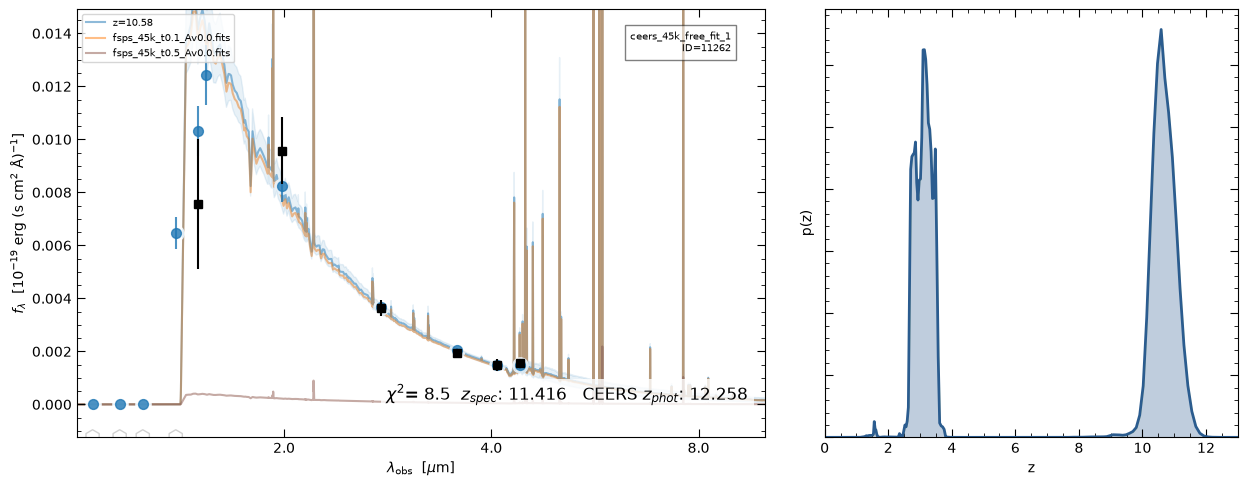

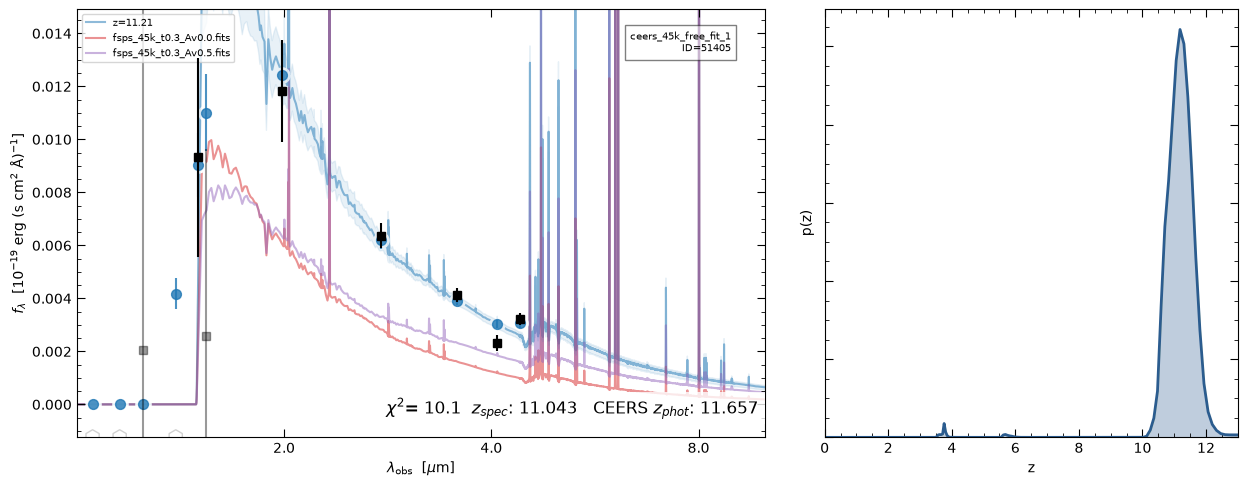

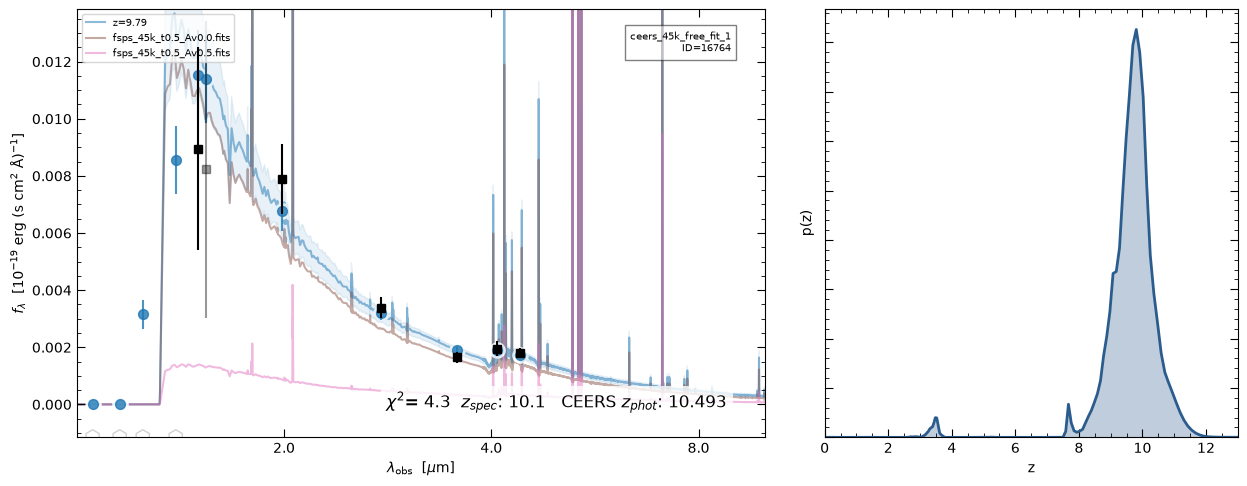

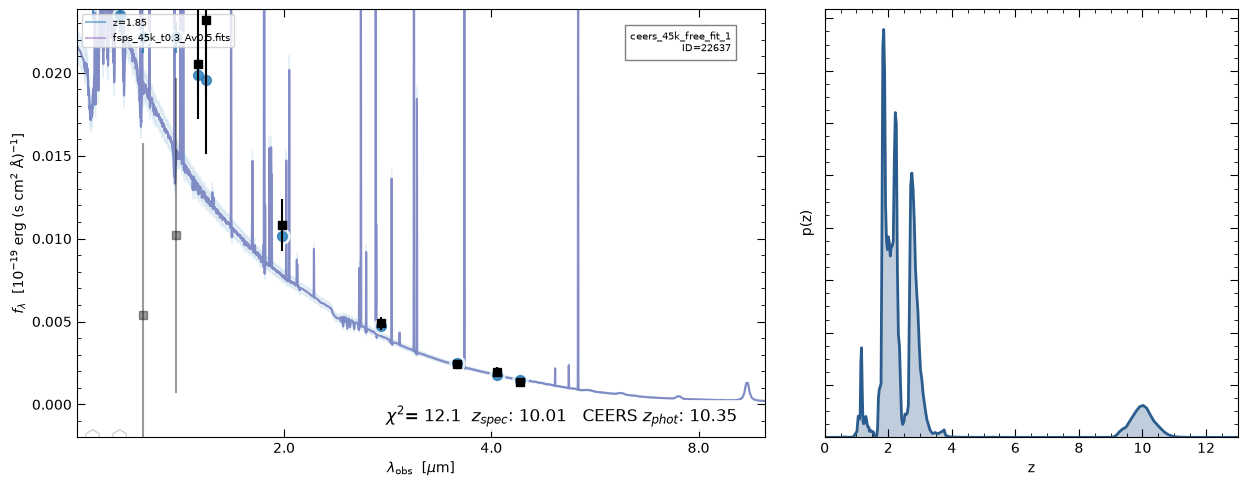

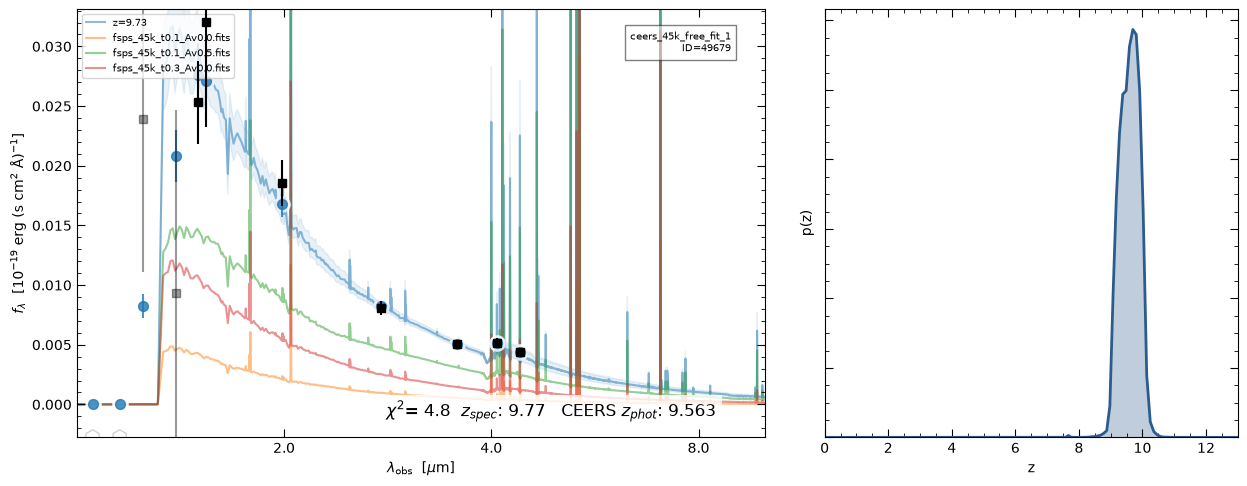

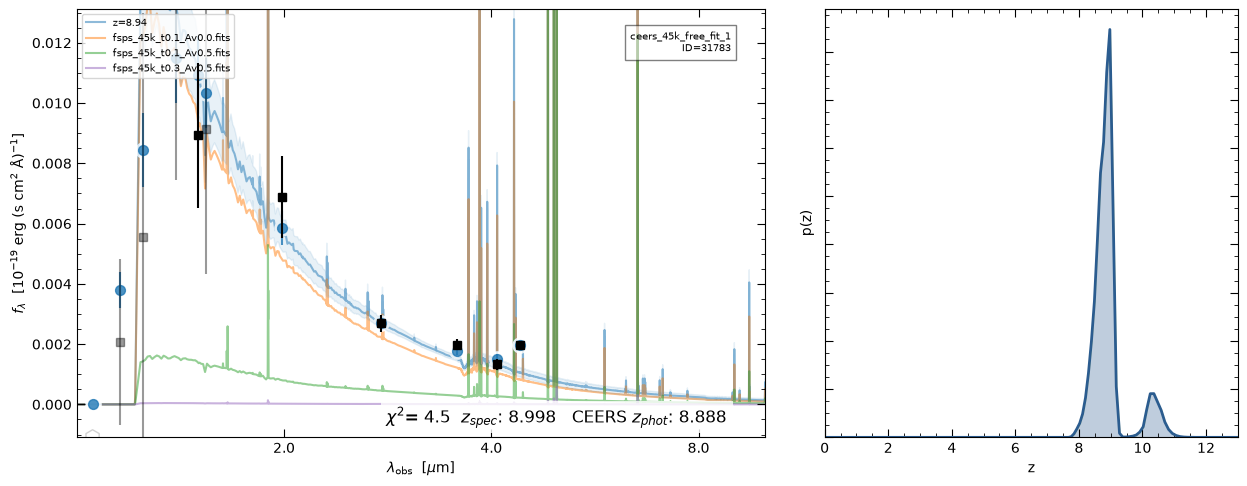

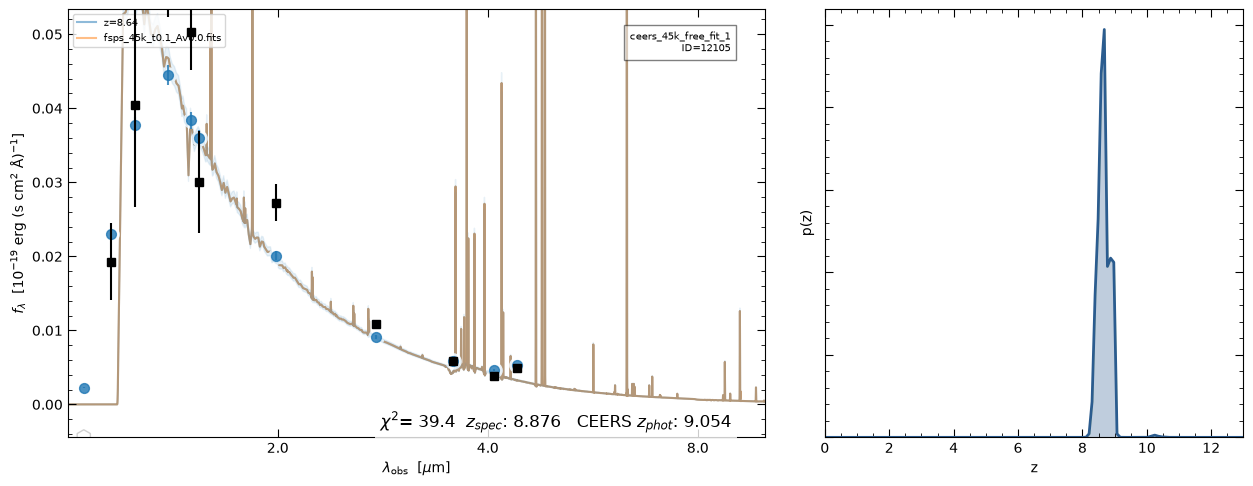

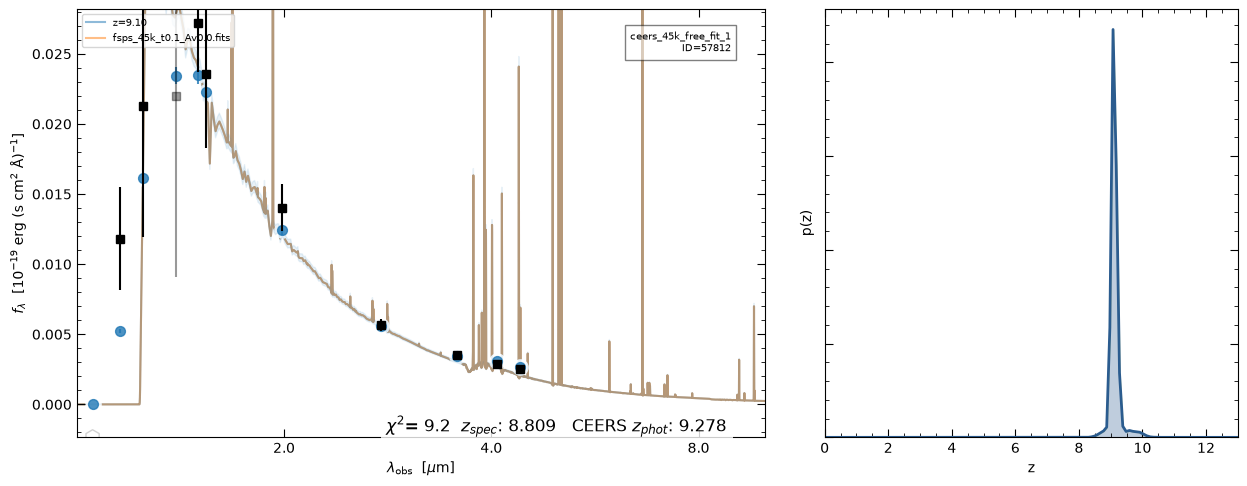

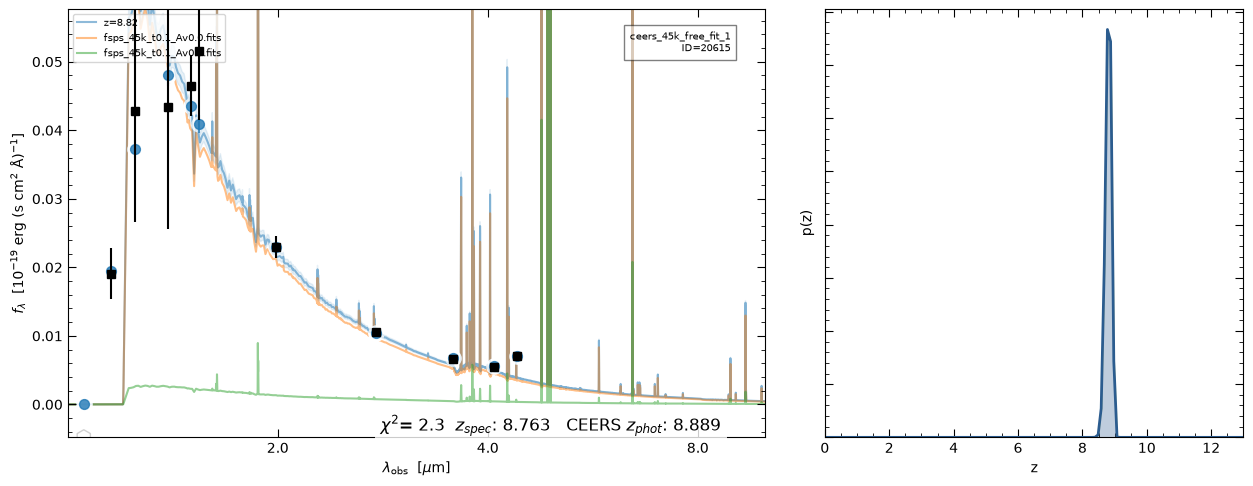

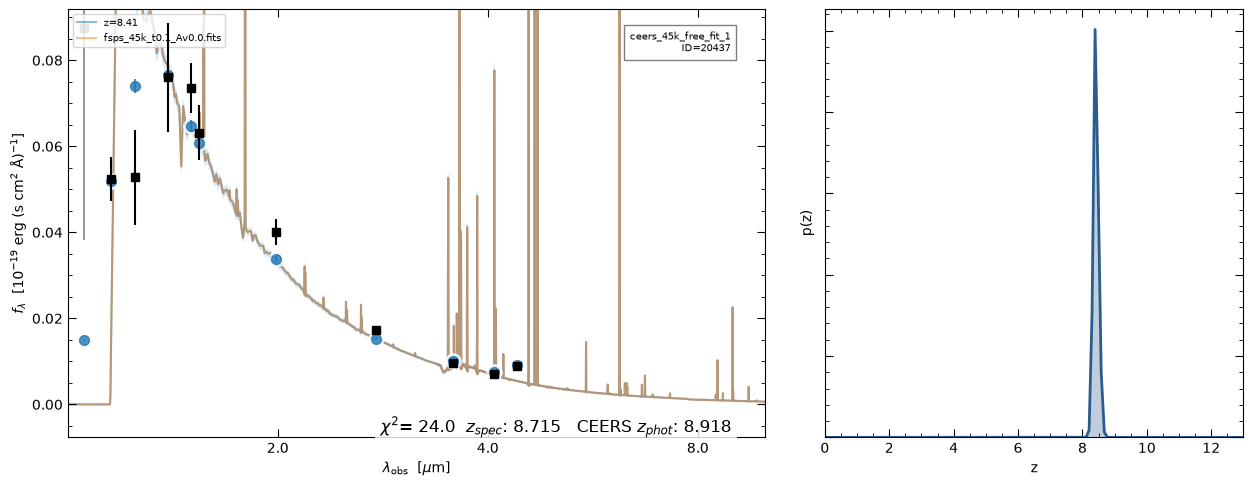

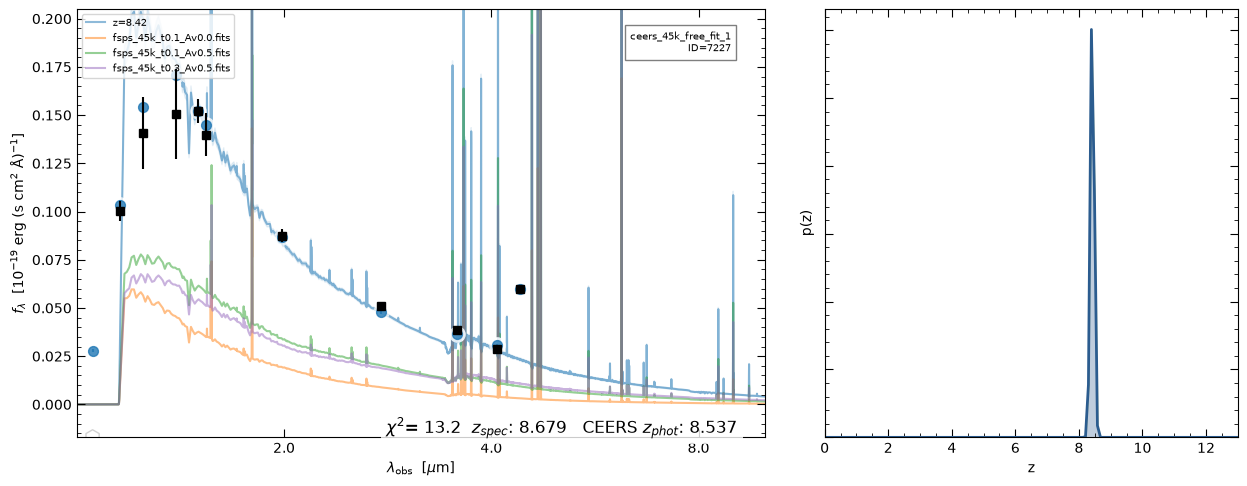

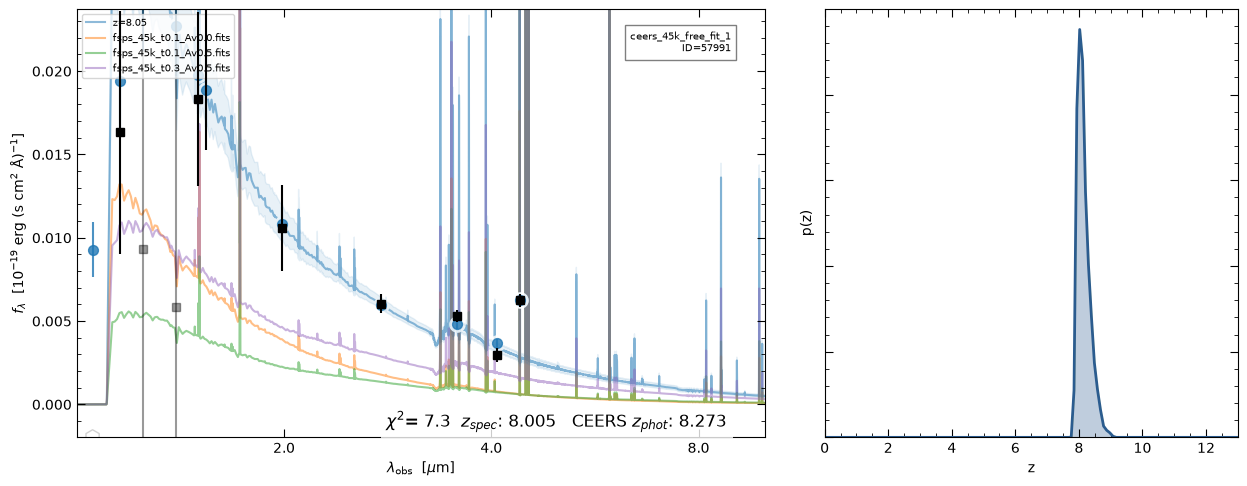

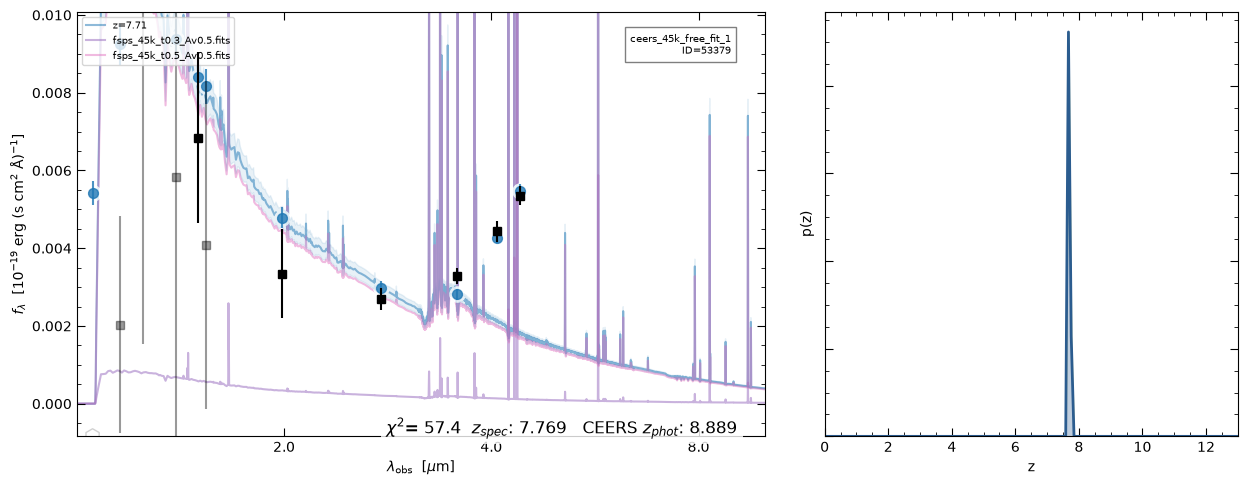

In [36]:
from matplotlib.ticker import AutoMinorLocator
ids_index = [35,168,53,84,165,105,40,204,73,72,25,206]
ids = ez.OBJID
mask1 = zout['z_phot'] > 0
zout_masked1 = zout[mask1]
ids_masked1 = ids[mask1]


output_path = '/home/caltech-msanche3/SURF2026/scripts/ceers_45k_fit_1.zout.fits'
output_data = Table.read(output_path)
output_data = output_data[mask1]


'''
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991]
zspec = [11.416,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.763,8.715,8.679,8.005]
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273]
'''

ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991,53379]
zspec = [11.416,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.763,8.715,8.679,8.005,7.769] 
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273,8.889]
ids_index_free = [313,1430,479,648,1388,885,338,1619,580,575,203,1625,1485]

print(output_data[ids_index_free]['id','z_phot','z_phot_chi2','mass',])

# pass ID where ids[i] was previously passed
for i in range(len(ids)):
    fig, data = ez.show_fit(ids[i], xlim=[1, 10], show_components=True,
                            logpz=False, zr=[0,13])
    # grab ax & figs
    ax = plt.gca()
    fig = plt.gcf()
    
    # set size to be wider
    fig.set_size_inches(13, 5)
    
    # remove grid lines
    ax1 = fig.axes[0]
    ax2 = fig.axes[1]
    ax1.grid(False)
    ax2.grid(False)
    
    # change p(z)
    ax1 = fig.axes[1]
    for line in ax1.get_lines():
        line.set_color('#2b5c8f')   
        line.set_linewidth(2.0)     
    for collection in ax1.collections:
        collection.set_facecolor('#2b5c8f') 
        collection.set_alpha(0.3)          
    if ax1.get_legend():
        ax1.legend(frameon=False)


    for ax in fig.axes:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        
        ax.tick_params(
            axis='both', 
            which='both', 
            direction='in',  
            top=True,        
            right=True
        )
        
        ax.tick_params(axis='both', which='major', length=6)
        ax.tick_params(axis='both', which='minor', length=3)

    ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index_free[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"CEERS $z_{phot}$: " f"{ceers_zphot[i]}", 
            fontsize=12,
            color='k',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')) 

ids_index_free = [313,1430,479,648,1388,885,338,1619,580,575,203,1625,1485]